# Titanic Survival Analysis

**Objective:** Explore the Titanic dataset, clean and preprocess it, perform exploratory data analysis (EDA), and engineer features to prepare the dataset for a Machine Learning model.

**Dataset:** 891 passengers, 12 original columns (`Titanic.csv`)

**Structure of this notebook:**
1. Data Understanding & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Final Processed Dataset & Summary Report


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("Titanic.csv")
df.head()


## 1. Data Understanding & Preprocessing

### 1.1 Basic Structure


In [2]:
print("Shape:", df.shape)
df.info()


Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Columns explained:**

| Column | Meaning |
|---|---|
| PassengerId | Unique row identifier |
| Survived | Target variable: 0 = Died, 1 = Survived |
| Pclass | Ticket class: 1 = 1st (upper), 2 = 2nd (middle), 3 = 3rd (lower) |
| Name | Passenger name (contains title, e.g. Mr., Mrs., Miss.) |
| Sex | male / female |
| Age | Age in years |
| SibSp | # of siblings/spouses aboard |
| Parch | # of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |


### 1.2 Missing Values

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing Count", ascending=False)


**Observations:**
- `Cabin` is missing for ~77% of passengers — too sparse to reliably impute; we'll engineer a simpler feature from it instead of trying to fill in the actual cabin numbers.
- `Age` is missing for ~20% of passengers — meaningful enough to keep, but needs sensible imputation.
- `Embarked` is missing for only 2 passengers — safe to fill with the most common port.


### 1.3 Duplicate Rows

In [4]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


No duplicate rows found — no action needed here.

### 1.4 Handling Missing Values

In [5]:
df_clean = df.copy()

# Age: impute using the median age WITHIN each passenger class,
# since wealthier (1st class) passengers tended to be older than 3rd class passengers.
# This is more accurate than a single global median.
df_clean["Age"] = df_clean.groupby("Pclass")["Age"].transform(lambda x: x.fillna(x.median()))

# Embarked: only 2 missing values - fill with the mode (most frequent port)
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Cabin: too many missing values to impute meaningfully.
# Instead of dropping the column entirely, we extract whether a cabin was RECORDED at all -
# this itself may correlate with class/fare and is more useful than the raw cabin number.
df_clean["Has_Cabin"] = df_clean["Cabin"].notnull().astype(int)
df_clean.drop(columns=["Cabin"], inplace=True)

print(df_clean.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


**Why median-by-class instead of a single global median for Age?**
Median age differs noticeably by class (1st class median ≈ 37, 2nd ≈ 29, 3rd ≈ 24), so imputing with one overall median would distort the age distribution within each class. Grouped imputation preserves this real pattern.


### 1.5 Outlier Analysis (Fare)

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


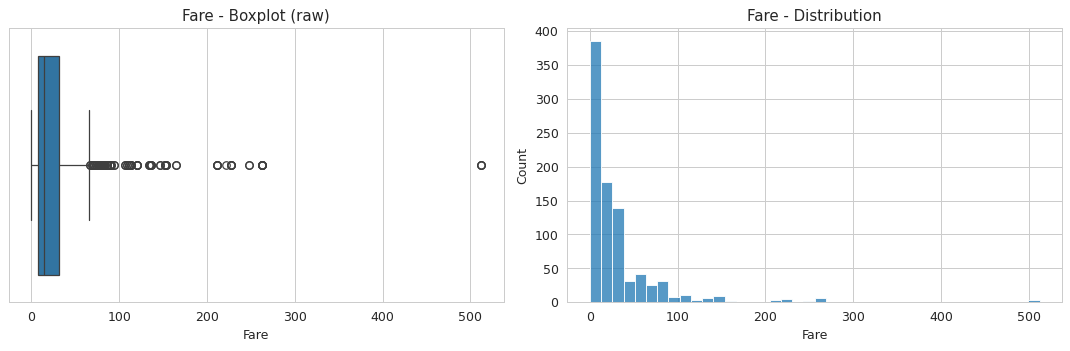

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_clean["Fare"], ax=axes[0])
axes[0].set_title("Fare - Boxplot (raw)")

sns.histplot(df_clean["Fare"], bins=40, ax=axes[1])
axes[1].set_title("Fare - Distribution")
plt.tight_layout()
plt.show()

print(df_clean["Fare"].describe())


**Observation:** Fare is heavily right-skewed with some high-value outliers (a small number of passengers paid very high fares, consistent with 1st class luxury tickets). 

**Decision:** We keep these outliers rather than removing them — they are genuine, valid data points (not data-entry errors) and likely carry real predictive signal (high fare strongly relates to class and survival). We will apply a log transform later during feature engineering to reduce the skew's impact on modeling, rather than deleting real passengers.


## 2. Exploratory Data Analysis (EDA)

### 2.1 Overall Survival Rate

Overall survival rate: 38.4%


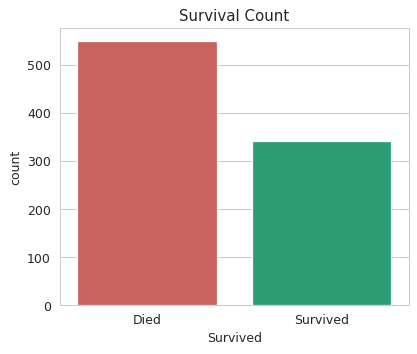

In [7]:
survival_rate = df_clean["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

plt.figure(figsize=(5,4))
sns.countplot(x="Survived", data=df_clean, hue="Survived", palette=["#d9534f", "#1baf7a"], legend=False)
plt.xticks([0, 1], ["Died", "Survived"])
plt.title("Survival Count")
plt.show()


### 2.2 Survival by Sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


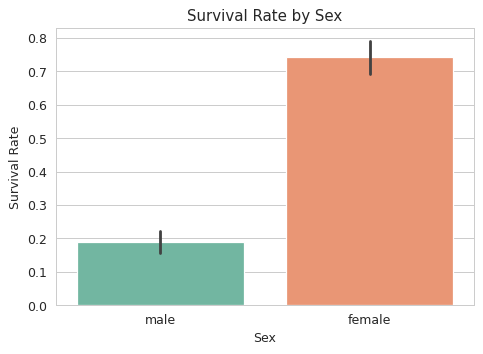

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(x="Sex", y="Survived", data=df_clean, hue="Sex", palette="Set2", legend=False)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

print(df_clean.groupby("Sex")["Survived"].mean())


**Insight:** Female passengers survived at ~74%, versus ~19% for male passengers — one of the strongest patterns in the dataset, consistent with the historical "women and children first" evacuation policy.


### 2.3 Survival by Passenger Class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


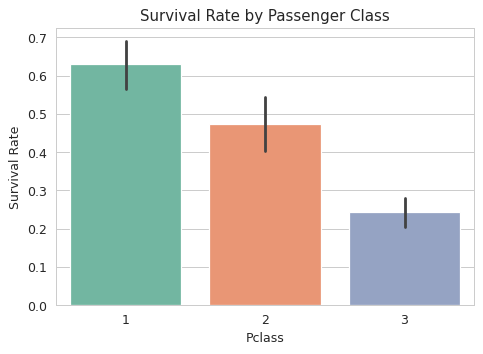

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(x="Pclass", y="Survived", data=df_clean, hue="Pclass", palette="Set2", legend=False)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

print(df_clean.groupby("Pclass")["Survived"].mean())


**Insight:** Survival rate drops steadily from 1st class (~63%) to 2nd (~47%) to 3rd class (~24%) — wealthier passengers had noticeably better access to lifeboats.


### 2.4 Age Distribution and Survival

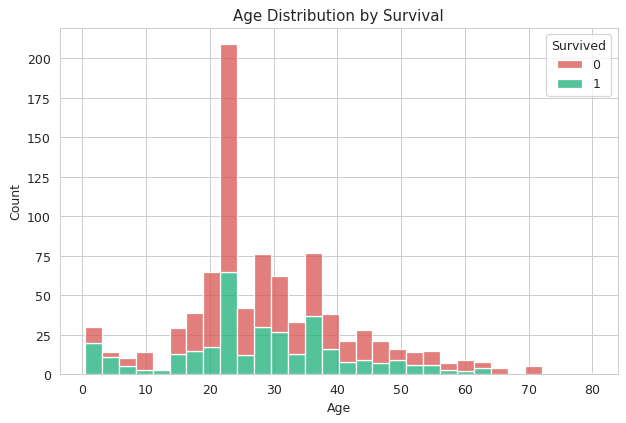

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x="Age", hue="Survived", multiple="stack", bins=30, palette=["#d9534f", "#1baf7a"])
plt.title("Age Distribution by Survival")
plt.show()


**Insight:** Young children (roughly under age 10) show a visibly higher survival share relative to their group size, again consistent with priority evacuation for children. Passengers in their 20s-30s form the bulk of the dataset, with survival mixed across the wider adult range.


### 2.5 Survival by Port of Embarkation

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


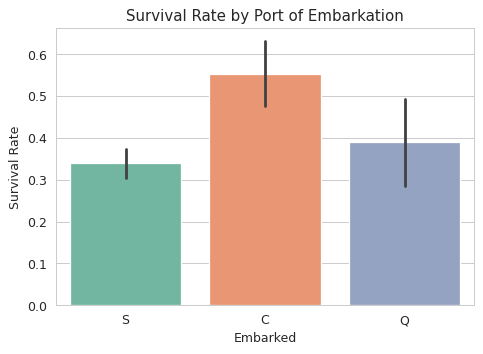

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(x="Embarked", y="Survived", data=df_clean, hue="Embarked", palette="Set2", legend=False)
plt.title("Survival Rate by Port of Embarkation")
plt.ylabel("Survival Rate")
plt.show()

print(df_clean.groupby("Embarked")["Survived"].mean())


**Insight:** Passengers who boarded at Cherbourg (C) had a notably higher survival rate (~55%) than Southampton (~34%) or Queenstown (~39%). This likely isn't a direct causal effect of the port itself, but a proxy — Cherbourg had a higher proportion of 1st class passengers.


### 2.6 Family Size and Survival

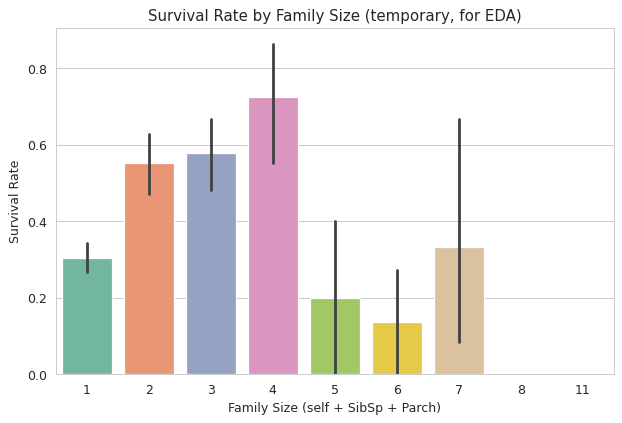

In [12]:
df_clean["FamilySize_temp"] = df_clean["SibSp"] + df_clean["Parch"] + 1

plt.figure(figsize=(8,5))
sns.barplot(x="FamilySize_temp", y="Survived", data=df_clean, hue="FamilySize_temp", palette="Set2", legend=False)
plt.title("Survival Rate by Family Size (temporary, for EDA)")
plt.ylabel("Survival Rate")
plt.xlabel("Family Size (self + SibSp + Parch)")
plt.show()

df_clean.drop(columns=["FamilySize_temp"], inplace=True)  # will re-add properly in Feature Engineering


**Insight:** Passengers travelling completely alone (family size = 1) or in very large families (6+) had notably lower survival rates than those in small-to-medium families (2-4). This suggests a "sweet spot" — too alone means no help, too large a family may have been harder to evacuate together. This motivates engineering a `FamilySize` and `IsAlone` feature.


### 2.7 Correlation Heatmap (numeric features)

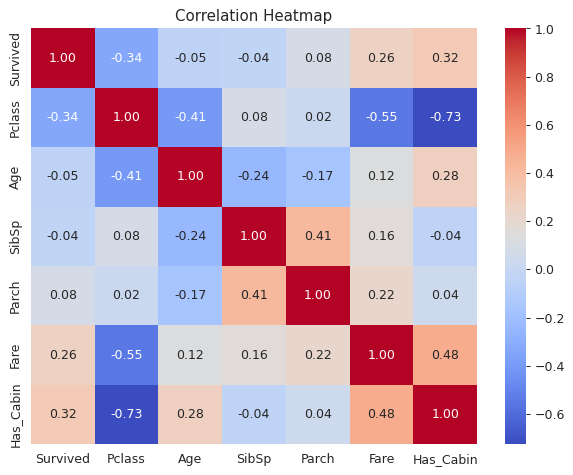

In [13]:
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Has_Cabin"]
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


**Insight:** `Pclass` has a fairly strong negative correlation with `Survived` (higher class number = lower survival), and `Fare`/`Has_Cabin` correlate positively with survival — both consistent with the class-based patterns seen above. `SibSp` and `Parch` individually show weak correlation, but as we saw above, their *combination* (family size) shows a clearer non-linear pattern — a good reason to engineer a combined feature rather than relying on the raw columns alone.


## 3. Feature Engineering

### 3.1 Title Extraction from Name

In [14]:
df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^\.]*)\.")

print(df_clean["Title"].value_counts())


Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


**Justification:** The raw `Name` column itself isn't usable by a model, but it hides a genuinely useful signal - the title (Mr./Mrs./Miss/Master/etc.) captures age group, sex, and social status all at once. We simplify rare titles into broader, more model-friendly categories below.


In [15]:
title_map = {
    "Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master",
    "Dr": "Rare", "Rev": "Rare", "Col": "Rare", "Major": "Rare",
    "Mlle": "Miss", "Mme": "Mrs", "Don": "Rare", "Lady": "Rare",
    "Countess": "Rare", "Jonkheer": "Rare", "Sir": "Rare",
    "Capt": "Rare", "Ms": "Miss"
}
df_clean["Title"] = df_clean["Title"].map(title_map).fillna("Rare")
print(df_clean["Title"].value_counts())


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


### 3.2 Family Size and IsAlone

In [16]:
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)

df_clean[["SibSp", "Parch", "FamilySize", "IsAlone"]].head()


**Justification:** As seen in EDA (2.6), raw `SibSp`/`Parch` individually showed a weak relationship with survival, but combining them into `FamilySize` revealed a clear pattern (a "sweet spot" for survival). `IsAlone` isolates the specific, sharply different outcome for solo travelers.


### 3.3 Age Groups

In [17]:
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

df_clean["AgeGroup"].value_counts()


**Justification:** EDA showed children had a visibly different survival pattern than adults. Binning `Age` into categories lets a model pick up on these threshold effects more directly than a continuous number alone.


### 3.4 Fare Transformation

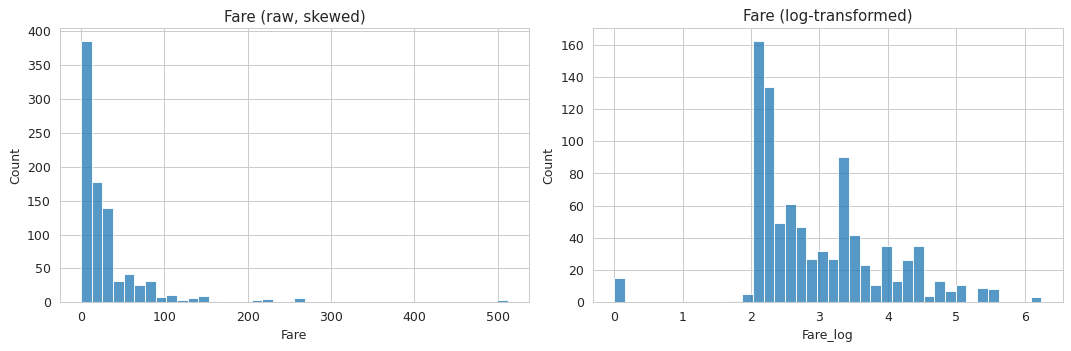

In [18]:
df_clean["Fare_log"] = np.log1p(df_clean["Fare"])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df_clean["Fare"], bins=40, ax=axes[0])
axes[0].set_title("Fare (raw, skewed)")
sns.histplot(df_clean["Fare_log"], bins=40, ax=axes[1])
axes[1].set_title("Fare (log-transformed)")
plt.tight_layout()
plt.show()


**Justification:** As noted in the outlier analysis (1.5), Fare is heavily right-skewed. A log transform (`log1p` handles the Fare=0 cases safely) compresses the extreme high values without discarding real passengers, giving models a more balanced feature to work with.


### 3.5 Encoding Categorical Variables

In [19]:
df_model = df_clean.copy()

# Binary encode Sex
df_model["Sex"] = df_model["Sex"].map({"male": 0, "female": 1})

# One-hot encode Embarked, Title, AgeGroup
df_model = pd.get_dummies(df_model, columns=["Embarked", "Title", "AgeGroup"], drop_first=True)

# Drop columns not usable directly by a model
df_model.drop(columns=["Name", "Ticket", "PassengerId", "Fare"], inplace=True)

df_model.head()


**Justification for each drop:**
- `Name`, `Ticket` — free-text/identifier fields with no direct numeric meaning; their useful signal (title) has already been extracted into `Title`.
- `PassengerId` — a row index, carries no real information.
- `Fare` — replaced by `Fare_log`, which is the better-behaved version for modeling.

**Justification for encoding choices:**
- `Sex` — binary encoded (0/1) since it only has two categories.
- `Embarked`, `Title`, `AgeGroup` — one-hot encoded (`drop_first=True` to avoid redundant/collinear columns) since they're unordered categories with more than two values.


### 3.6 Final Feature Set

In [20]:
print("Final shape:", df_model.shape)
print()
print("Final columns:")
print(list(df_model.columns))
print()
df_model.info()


Final shape: (891, 20)

Final columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Has_Cabin', 'FamilySize', 'IsAlone', 'Fare_log', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teen', 'AgeGroup_YoungAdult', 'AgeGroup_Adult', 'AgeGroup_Senior']

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Survived             891 non-null    int64  
 1   Pclass               891 non-null    int64  
 2   Sex                  891 non-null    int64  
 3   Age                  891 non-null    float64
 4   SibSp                891 non-null    int64  
 5   Parch                891 non-null    int64  
 6   Has_Cabin            891 non-null    int64  
 7   FamilySize           891 non-null    int64  
 8   IsAlone              891 non-null    int64  
 9   Fare_log             891 non-null    float64
 10

## 4. Save Processed Dataset

In [21]:
df_model.to_csv("Titanic_processed.csv", index=False)
print("Saved: Titanic_processed.csv")


Saved: Titanic_processed.csv


## 5. Summary Report

### Data Cleaning
- No duplicate rows were found.
- `Age` (177 missing, ~20%) was imputed using the **median age within each passenger class**, since median age varies meaningfully by class (1st ≈ 37, 2nd ≈ 29, 3rd ≈ 24) — a single global median would have distorted this.
- `Embarked` (2 missing) was filled with the most frequent port (mode).
- `Cabin` (687 missing, ~77%) was too sparse to impute reliably. Instead of dropping all its information, we engineered a binary `Has_Cabin` feature and dropped the raw column.
- `Fare` outliers (a small number of very high fares) were kept as genuine data and addressed via a log transform (`Fare_log`) rather than removal, since they carry real predictive signal (linked to class/survival).

### Key EDA Insights
1. **Sex is the strongest single predictor** — female survival rate (~74%) vs male (~19%).
2. **Class matters substantially** — survival drops from ~63% (1st class) to ~24% (3rd class).
3. **Children had a survival advantage** relative to their share of the population.
4. **Port of embarkation correlates with survival** (Cherbourg highest), largely as a proxy for class composition rather than a direct cause.
5. **Family size shows a "sweet spot"** — solo travelers and very large families both fared worse than small-to-medium family groups.

### Feature Engineering Summary
| New Feature | Built From | Why |
|---|---|---|
| `Has_Cabin` | Cabin (missingness) | Cabin data was too sparse to use directly, but its presence/absence still carries signal |
| `Title` | Name | Captures age/sex/social-status signal hidden in the name text |
| `FamilySize`, `IsAlone` | SibSp + Parch | Combined signal was clearer than either raw column alone |
| `AgeGroup` | Age | Captures threshold effects (e.g. child survival advantage) that raw age alone understates |
| `Fare_log` | Fare | Reduces the impact of Fare's right-skew/outliers for modeling |

### Dataset Ready for Modeling
The final processed dataset (`Titanic_processed.csv`) contains fully numeric, encoded features with no missing values, ready to be used directly with any standard Machine Learning model (e.g. Logistic Regression, Random Forest, etc.) in a next step.
